# Setup — GW viewing-angle distribution $p(d, \theta_{\rm v})$

Auxiliary notebook, run **per GW alert** — unlike `setup_model.ipynb` (the
emission model, run once), this depends on that alert's own GW data. It
implements Step 4.3 of the simulation guidelines: drawing the viewing angle
$\theta_i$ given the distance $d_i$ drawn in the same iteration.

The central object is the **joint** $p(d_L, \theta_{\rm v})$. Everything the
pipeline needs follows from it:

| question | operation | method |
| --- | --- | --- |
| $\theta_i$ once $d_i$ is drawn (sim_3d, every iteration) | condition on $d$: $p(\theta \mid d_i) = p(d_i,\theta)/p(d_i)$ | `ThetaDistribution.sample(n, distance_Mpc=d)` |
| the distance if the angle is known (e.g. from an EM counterpart) | condition on $\theta$: $p(d \mid \theta_0)$ or $p(d \mid a<\theta<b)$ | `joint.conditional_distance(...)` |
| one variable regardless of the other | marginalise | `joint.marginal_distance()`, `joint.marginal_theta()` |
| (RA, Dec, $d$, $\theta$) together | resample PE sample indices | `ThetaDistribution.sample_joint(n)` |

Which joint is available depends on what LVK has released for the alert:

| information available | `kind` | $\theta$ depends on $d$? | notebook part |
| --- | --- | --- | --- |
| PE posterior samples (GWTC data release) | `"pe"` | yes, from the event's own posterior | Part 1 |
| nothing event-specific; GW-detected population with a horizon | `"selection"` | yes, near the horizon only face-on binaries are detected | Part 2 |
| Schutz (2011) GW-detected-source distribution | `"schutz"` | no | Part 2 |
| geometric isotropic prior | `"isotropic"` | no | Part 2 |
| $\theta$ fixed by assumption / a dummy two-bin split | `"fixed"` / `"two_bin"` | no | Part 2 |

Whichever applies, the notebook ends by writing **one standardized cache**,
`data/gw_input/<source_name>_theta_distribution.npz`, which `sim_3d` loads with
one call and never needs to know which case produced it.

Code: [`gwuls/gw_pe.py`](../gwuls/gw_pe.py) (PE files),
[`gwuls/angle_distribution.py`](../gwuls/angle_distribution.py) (the distributions),
[`gwuls/plotting.py`](../gwuls/plotting.py) (the figures). Viewing angle throughout:
$\theta_{\rm v} = \min(\theta_{JN}, 180^\circ-\theta_{JN}) \in [0^\circ, 90^\circ]$,
the angle to the nearer jet axis. Every pdf is normalised **per degree**, so all
options can be compared on one axis.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import matplotlib.pyplot as plt

from gwuls import angle_distribution as angdist, gw_pe, paths, plotting
from importlib import reload
reload(gw_pe); reload(angdist); reload(plotting)

paths.ensure_dirs()

def quantiles(x, pdf, qs=(0.05, 0.5, 0.95)):
    # quantiles of a tabulated pdf (trapezoid CDF)
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))])
    return np.interp(qs, cdf / cdf[-1], x)

## Parameters

`source_name` is the LVK **superevent ID** — the name the alert went out under,
the name of its skymap in `data/gw_input/`, and the name the standardized PE
file gets.

In [2]:
source_name = "S240615dg"

# Part 0 -- raw PE release -> light per-alert file
N_PER_ANALYSIS         = 5000    # posterior samples kept per waveform analysis (same for all -> equal-weight mixture)
OVERWRITE_STANDARDIZED = False   # True rebuilds data/gw_pe/standardized/<alert>.h5 from the raw file

# Part 1 -- KDE of p(d, theta_v) from the PE samples
BW_SCALE = 1.0                   # kernel bandwidth = Scott's rule x BW_SCALE (sensitivity checked below)

# Part 2 -- options without PE
HORIZON_MPC     = 3000.0         # "selection" only: network horizon for this source type. ILLUSTRATIVE here --
                                 # set it from the detector sensitivity if you use this option for real.
FIXED_THETA_DEG = 20.0
TWO_BIN         = dict(threshold_deg=45.0, p_below=0.5)

rng = np.random.default_rng(42)

## Part 0 — PE data: raw release → light per-alert file

The GWTC PE data releases (`*-combined_PEDataRelease.hdf5`, from Zenodo) are
0.2–7 GB per event: several waveform analyses × ~15k samples × ~180 columns,
plus PSDs, calibration envelopes and skymaps. They live in
`data/gw_pe/raw/` (**gitignored**). Download new ones there, together with the
catalog's `*-PESummaryTable.hdf5` (it maps GWTC names to superevent IDs).

`gw_pe.standardize_all()` turns each one into
`data/gw_pe/standardized/<superevent>.h5` (~1 MB, **tracked in git**), keeping:

- sky position, $d_L$, $z$, $\theta_{JN}$, $\iota$, source-frame masses,
  $\chi_{\rm eff}$, tidal deformabilities (when present), network SNR;
- the **same number of samples from every waveform analysis**, tagged, so the
  file is directly the equal-weight mixture the LVK catalog papers quote, and
  each analysis can still be compared on its own;
- the PE prior samples of $(d_L, \theta_{JN})$, and each analysis's prior
  definitions, approximant, $f_{\rm ref}$, cosmology and detectors.

`data/gw_pe/standardized/index.csv` is regenerated from those files every time,
one row per alert: the running list of alerts whose PE has been released and
standardized. On a machine without the raw files (e.g. the cluster) this part
just reads the tracked files.

In [3]:
releases = gw_pe.list_raw_releases()
if releases:
    print(f"{'GW name':<18}{'alert':<12}{'catalog':<10}{'size':>10}  standardized")
    for r in releases:
        print(f"{r['gw_name']:<18}{str(r['superevent_id']):<12}{r['catalog']:<10}"
              f"{r['size_GB']:>7.2f} GB  {r['standardized']}")
    gw_pe.standardize_all(n_per_analysis=N_PER_ANALYSIS, overwrite=OVERWRITE_STANDARDIZED)
else:
    print(f"no raw PE releases in {paths.GW_PE_RAW_DIR} -- using the tracked standardized files")
gw_pe.rebuild_index()

print(f"\nKnown alerts with released PE ({paths.GW_PE_STANDARDIZED_DIR.relative_to(paths.REPO_ROOT)}/index.csv):")
print(f"{'alert':<12}{'GW name':<18}{'catalog':<10}{'d_L [Mpc] (90%)':<22}{'theta_v [deg] (90%)':<22}"
      f"{'P(theta_v<30)':>14}{'m1, m2 [Msun]':>16}")
for row in gw_pe.read_index():
    print(f"{row['superevent_id']:<12}{row['gw_name']:<18}{row['catalog']:<10}"
          f"{row['distance_Mpc_median'] + ' [' + row['distance_Mpc_q05'] + ', ' + row['distance_Mpc_q95'] + ']':<22}"
          f"{row['viewing_angle_deg_median'] + ' [' + row['viewing_angle_deg_q05'] + ', ' + row['viewing_angle_deg_q95'] + ']':<22}"
          f"{row['p_viewing_angle_below_30deg']:>14}{row['mass_1_source_median'] + ', ' + row['mass_2_source_median']:>16}")

GW name           alert       catalog         size  standardized
GW240615_113620   S240615dg   GWTC-5.0     6.59 GB  True
GW241125_010116   S241125n    GWTC-5.0     0.21 GB  True

Known alerts with released PE (data/gw_pe/standardized/index.csv):
alert       GW name           catalog   d_L [Mpc] (90%)       theta_v [deg] (90%)    P(theta_v<30)   m1, m2 [Msun]
S240615dg   GW240615_113620   GWTC-5.0  1566 [1123, 1849]     24.4 [6.5, 51.1]               0.647        34.1, 26
S241125n    GW241125_010116   GWTC-5.0  4748 [2600, 8611]     55.8 [15.6, 86.0]              0.168      59.3, 46.1


**Check — does the light file lose anything?** For each analysis, compare the
stored subset against the *full* raw posterior (percentiles of $\theta_{\rm v}$
and $d_L$), and our fold $\min(\theta_{JN}, 180^\circ-\theta_{JN})$ against the
`viewing_angle` column pesummary itself writes. Only runs where the raw file is
present.

In [4]:
raw = next((r for r in releases if r["superevent_id"] == source_name), None)
pe = gw_pe.load_pe(source_name) if source_name in gw_pe.known_alerts() else None

if raw is not None and pe is not None:
    import h5py
    print(f"{'analysis':<30}{'n full':>8}{'n kept':>8}   theta_v q5/50/95 full | kept      "
          f"d_L q5/50/95 full | kept          max|fold - pesummary|")
    with h5py.File(raw["path"], "r") as f:
        for a in pe.analyses:
            ps = f[a]["posterior_samples"]
            t_full = gw_pe.fold_viewing_angle(np.degrees(ps["theta_jn"]))
            d_full = np.asarray(ps["luminosity_distance"])
            dev = (np.max(np.abs(t_full - np.degrees(ps["viewing_angle"])))
                   if "viewing_angle" in ps.dtype.names else np.nan)
            tq_f, tq_k = np.percentile(t_full, [5, 50, 95]), np.percentile(pe.get("viewing_angle_deg", a), [5, 50, 95])
            dq_f, dq_k = np.percentile(d_full, [5, 50, 95]), np.percentile(pe.get("distance_Mpc", a), [5, 50, 95])
            print(f"{a:<30}{t_full.size:>8}{(pe.analysis_index == pe.analyses.index(a)).sum():>8}   "
                  f"{'/'.join(f'{v:.1f}' for v in tq_f)} | {'/'.join(f'{v:.1f}' for v in tq_k)}   "
                  f"{'/'.join(f'{v:.0f}' for v in dq_f)} | {'/'.join(f'{v:.0f}' for v in dq_k)}   {dev:.1e} deg")
else:
    print("raw file not present (or alert not standardized) -- check skipped")

analysis                        n full  n kept   theta_v q5/50/95 full | kept      d_L q5/50/95 full | kept          max|fold - pesummary|
C00:IMRPhenomXPHM-SpinTaylor     14327    5000   6.4/24.2/52.1 | 6.2/24.3/52.3   1114/1565/1859 | 1120/1565/1865   4.4e-15 deg
C00:IMRPhenomXPNR                12522    5000   6.6/23.4/46.9 | 6.5/23.6/47.0   1206/1580/1851 | 1203/1577/1849   0.0e+00 deg
C00:NRSur7dq4                    15884    5000   7.1/25.8/51.4 | 6.9/25.4/51.7   1095/1570/1867 | 1080/1572/1866   0.0e+00 deg
C00:SEOBNRv5PHM                  15742    5000   6.6/24.6/52.3 | 6.5/24.3/53.2   1110/1552/1809 | 1101/1554/1811   0.0e+00 deg


## Part 1 — PE posterior: the joint $p(d_L, \theta_{\rm v})$

The joint is built as a Gaussian KDE of the mixed posterior samples on a
regular $(d_L, \theta_{\rm v})$ grid (`JointDistanceAngle.from_samples`):

- the KDE runs in $(d_L, \cos\theta_{\rm v})$, where any orientation posterior
  has a smooth, finite density at both edges, reflected at
  $\cos\theta_{\rm v}=0$ and $1$, then mapped back with the Jacobian
  $\sin\theta_{\rm v}$. A KDE directly in $\theta_{\rm v}$ would put spurious
  mass at $\theta_{\rm v}=0$, where the density per degree must vanish;
- the kernel has the samples' **full covariance** (Scott's rule), so it follows
  the $d$–$\theta$ correlation instead of blurring across it;
- binned + FFT convolution: 20k samples take well under a second.

The grid is what gets saved; the samples are also kept, for joint
(RA, Dec, $d$, $\theta$) draws.

In [5]:
if pe is not None:
    d_s, t_s = pe.get("distance_Mpc"), pe.get("viewing_angle_deg")
    dist_pe = angdist.make_theta_distribution("pe", pe=pe, bw_scale=BW_SCALE)
    J = dist_pe.joint
    print(f"{pe.superevent_id} = {pe.gw_name} ({pe.catalog}), {len(pe)} samples = "
          f"{len(pe.analyses)} analyses x {pe.meta['n_per_analysis']}")
    print(f"KDE: kernel sigma(d) = {J.meta['kernel_sigma_distance_Mpc']:.0f} Mpc, "
          f"sigma(cos theta_v) = {J.meta['kernel_sigma_cos_theta']:.3f}, "
          f"kernel correlation = {J.meta['kernel_correlation']:.2f}")
    print(f"grid: {J.distance_Mpc.size} distances x {J.theta_deg.size} angles; "
          f"distance support [{J.distance_support[0]:.0f}, {J.distance_support[1]:.0f}] Mpc")
else:
    dist_pe = None
    print(f"No standardized PE for {source_name} -- Part 1 is skipped; see Part 2 for the options without PE.")

S240615dg = GW240615_113620 (GWTC-5.0), 20000 samples = 4 analyses x 5000
KDE: kernel sigma(d) = 42 Mpc, sigma(cos theta_v) = 0.023, kernel correlation = 0.82
grid: 300 distances x 181 angles; distance support [380, 2352] Mpc


### The corner plot

Filled: the mixed (equal-weight) joint, with its 50% and 90% highest-density
contours; coloured contours: each waveform analysis on its own; faint dots and
grey histograms: the samples the KDE came from. The dotted line on
$p(\theta_{\rm v})$ is the isotropic PE prior — how far the posterior sits from
it is what the GW data say about the inclination.

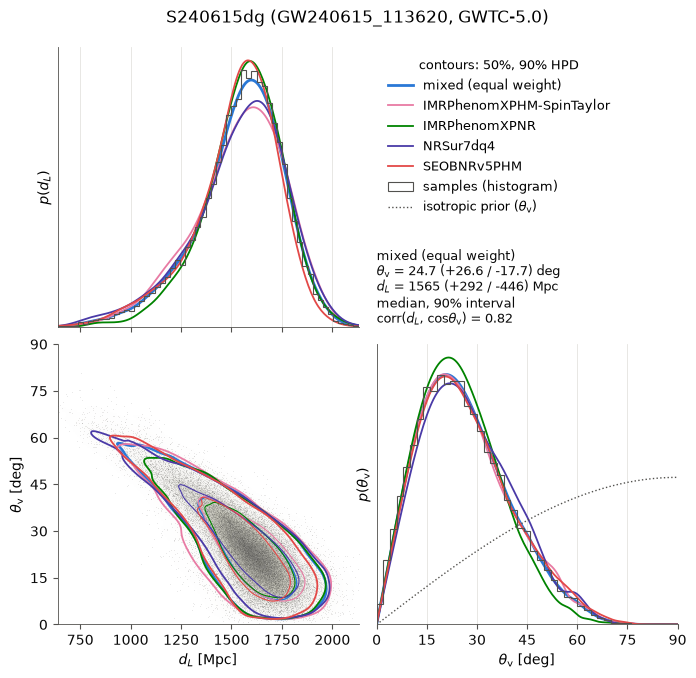

analysis                        theta_v median [90%]        d_L median [90%]  P(theta_v<30)
mixed (equal weight)                24.7 [7.0, 51.3]       1565 [1120, 1858]          0.641
IMRPhenomXPHM-SpinTaylor            24.7 [7.0, 52.4]       1563 [1107, 1878]          0.640
IMRPhenomXPNR                       23.9 [6.9, 47.3]       1576 [1197, 1859]          0.676
NRSur7dq4                           25.9 [7.4, 52.2]       1568 [1074, 1880]          0.606
SEOBNRv5PHM                         25.0 [7.1, 53.3]       1553 [1096, 1826]          0.630


In [6]:
if pe is not None:
    joints = {"mixed (equal weight)": J}
    colors = {"mixed (equal weight)": plotting.ANGLE_KIND_COLORS["pe"]}
    for a, c in zip(pe.analyses, plotting.ANALYSIS_COLORS):
        sub = pe.for_analysis(a)
        lab = a.replace("C00:", "")
        joints[lab] = angdist.JointDistanceAngle.from_samples(
            sub.get("distance_Mpc"), sub.get("viewing_angle_deg"), bw_scale=BW_SCALE)
        colors[lab] = c
    plotting.plot_distance_angle_corner(
        joints, colors=colors, samples=(d_s, t_s),
        title=f"{source_name} ({pe.gw_name}, {pe.catalog})",
        save_path=paths.plot_path(source_name, "theta_v_distance_corner.png"))

    print(f"{'analysis':<28}{'theta_v median [90%]':>24}{'d_L median [90%]':>24}{'P(theta_v<30)':>15}")
    for lab, JJ in joints.items():
        tq = quantiles(*JJ.marginal_theta()); dq = quantiles(*JJ.marginal_distance())
        t_, p_ = JJ.marginal_theta()
        p30 = np.trapezoid(p_[t_ <= 30], t_[t_ <= 30])
        print(f"{lab:<28}{f'{tq[1]:.1f} [{tq[0]:.1f}, {tq[2]:.1f}]':>24}"
              f"{f'{dq[1]:.0f} [{dq[0]:.0f}, {dq[2]:.0f}]':>24}{p30:>15.3f}")

### Check — the KDE grid against the samples it came from

Two independent estimates of the same quantities: quantiles of the grid's
marginals vs the raw samples, and the grid's conditional $p(\theta_{\rm v} \mid d)$
vs a grid-free estimate (resampling the samples with Gaussian weights in $d$,
`conditional_theta_by_resampling`). Differences of a fraction of a degree are
the KDE smoothing; anything larger would mean the grid or bandwidth is wrong.

In [7]:
if pe is not None:
    print("marginals        q05 / q50 / q95   samples              KDE grid")
    for name, x, (g, p) in [("theta_v [deg]", t_s, J.marginal_theta()), ("d_L [Mpc]", d_s, J.marginal_distance())]:
        a_, b_ = np.percentile(x, [5, 50, 95]), quantiles(g, p)
        print(f"  {name:<15}{'':17}{' / '.join(f'{v:7.1f}' for v in a_)}   {' / '.join(f'{v:7.1f}' for v in b_)}")

    d_pct = np.percentile(d_s, [5, 16, 50, 84, 95])
    print("\np(theta_v | d)   median, 90% interval   grid                    resampling")
    for q_, d0 in zip([5, 16, 50, 84, 95], d_pct):
        g, p = J.conditional_theta(d0)
        r_ = angdist.conditional_theta_by_resampling(t_s, d_s, d0, rng=rng)
        a_, b_ = quantiles(g, p), np.percentile(r_, [5, 50, 95])
        print(f"  d = {d0:6.0f} Mpc ({q_:>2}%)   {a_[1]:5.1f} [{a_[0]:4.1f}, {a_[2]:4.1f}]"
              f"      {b_[1]:5.1f} [{b_[0]:4.1f}, {b_[2]:4.1f}]")

marginals        q05 / q50 / q95   samples              KDE grid
  theta_v [deg]                       6.5 /    24.4 /    51.1       7.0 /    24.7 /    51.3
  d_L [Mpc]                        1123.4 /  1566.0 /  1849.3    1119.7 /  1565.3 /  1857.6

p(theta_v | d)   median, 90% interval   grid                    resampling
  d =   1123 Mpc ( 5%)    49.5 [38.9, 59.0]       49.3 [37.4, 59.4]
  d =   1333 Mpc (16%)    38.1 [20.6, 48.5]       37.8 [19.4, 48.6]
  d =   1566 Mpc (50%)    23.7 [ 8.3, 36.6]       23.3 [ 7.5, 36.7]
  d =   1743 Mpc (84%)    16.3 [ 4.9, 29.3]       16.2 [ 4.5, 29.5]
  d =   1849 Mpc (95%)    13.6 [ 4.1, 26.0]       13.6 [ 3.7, 26.4]


### $p(\theta_{\rm v} \mid d)$ along $d$: the distance–inclination degeneracy

The GW amplitude grows towards face-on and falls as $1/d$, so a face-on source
far away and a more inclined one nearby look alike. So the
angle drawn in an iteration must depend on that iteration's distance. Lines:
median and 5–95% of $p(\theta_{\rm v} \mid d)$; vertical lines: the 5%, 50%
and 95% points of $p(d)$.

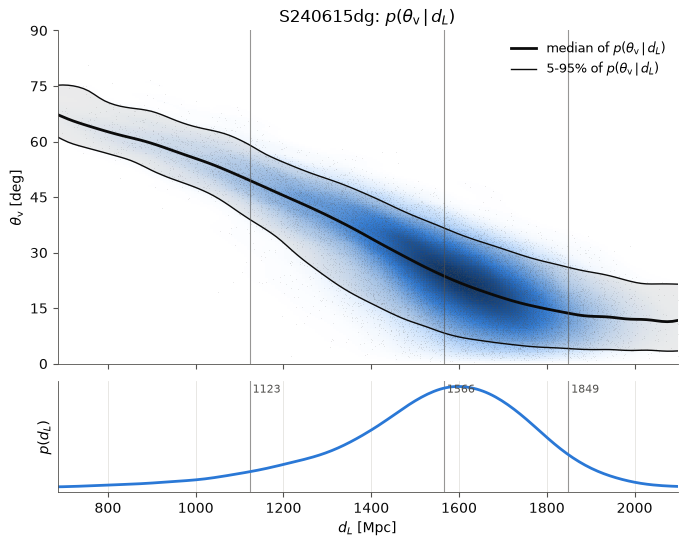

In [8]:
if pe is not None:
    plotting.plot_conditional_ridge(
        J, samples=(d_s, t_s), marks=np.percentile(d_s, [5, 50, 95]),
        title=rf"{source_name}: $p(\theta_{{\rm v}}\,|\,d_L)$",
        save_path=paths.plot_path(source_name, "theta_v_given_distance_ridge.png"))

Slices at fixed $d$ (the 5, 16, 50, 84, 95% points of $p(d)$): solid lines from
the grid, thin steps from the grid-free resampling, dashed the marginal
$p(\theta_{\rm v})$ — what you would draw if the distance were ignored.

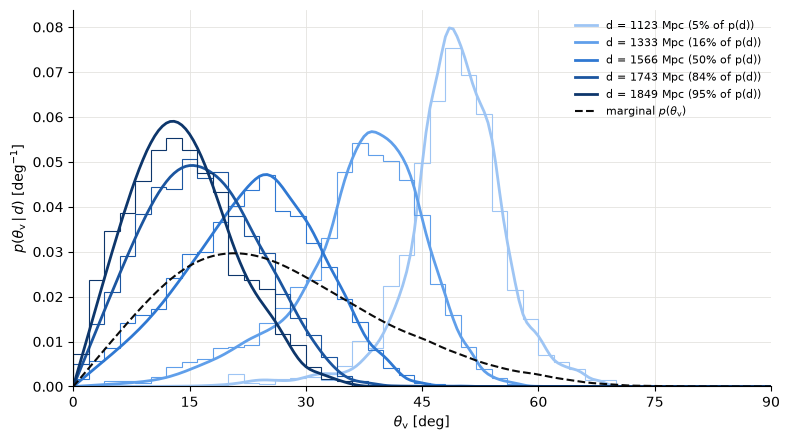

In [9]:
if pe is not None:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bins = np.linspace(0, 90, 46)
    for d0, c, q_ in zip(d_pct, plotting.blue_steps(len(d_pct)), [5, 16, 50, 84, 95]):
        g, p = J.conditional_theta(d0)
        ax.plot(g, p, color=c, lw=2, label=f"d = {d0:.0f} Mpc ({q_}% of p(d))")
        r_ = angdist.conditional_theta_by_resampling(t_s, d_s, d0, rng=rng)
        ax.hist(r_, bins=bins, density=True, histtype="step", color=c, lw=0.8)
    g, p = J.marginal_theta()
    ax.plot(g, p, color="#0b0b0b", lw=1.5, ls="--", label=r"marginal $p(\theta_{\rm v})$")
    ax.set_xlim(0, 90); ax.set_xticks(np.arange(0, 91, 15)); ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$\theta_{\rm v}$ [deg]"); ax.set_ylabel(r"$p(\theta_{\rm v}\,|\,d)$ [deg$^{-1}$]")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, color="#e4e3df", lw=0.6); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(paths.plot_path(source_name, "theta_v_given_distance_slices.png"), dpi=150)
    plt.show()

### Check — bandwidth sensitivity

The only free choice in the KDE is the bandwidth. Halving and doubling it
should move the conditional medians by much less than their widths.

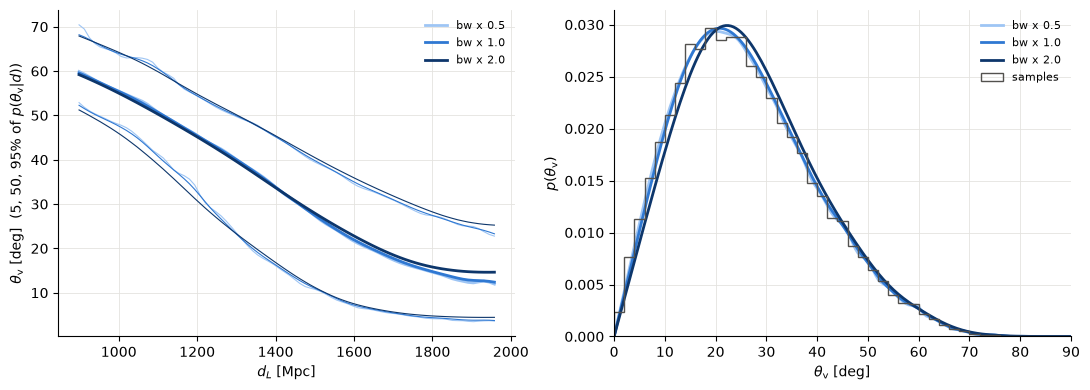

median of p(theta_v | d) [deg]:
   d [Mpc]    bw x 0.5    bw x 1.0    bw x 2.0
      1123        49.5        49.5        49.1
      1333        38.2        38.1        37.7
      1566        23.5        23.7        24.5
      1743        16.0        16.3        17.1
      1849        13.2        13.6        15.1


In [10]:
if pe is not None:
    bws = (0.5, 1.0, 2.0)
    joints_bw = {bw: (J if bw == BW_SCALE else angdist.JointDistanceAngle.from_samples(d_s, t_s, bw_scale=bw))
                 for bw in bws}
    dgrid = np.linspace(*np.percentile(d_s, [1, 99]), 80)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    for (bw, JJ), c in zip(joints_bw.items(), plotting.blue_steps(len(bws))):
        qq = JJ.conditional_theta_quantiles((0.05, 0.5, 0.95), distance_Mpc=dgrid)
        ax1.plot(dgrid, qq[:, 1], color=c, lw=2, label=f"bw x {bw}")
        ax1.plot(dgrid, qq[:, 0], color=c, lw=0.8); ax1.plot(dgrid, qq[:, 2], color=c, lw=0.8)
        ax2.plot(*JJ.marginal_theta(), color=c, lw=2, label=f"bw x {bw}")
    ax2.hist(t_s, bins=np.linspace(0, 90, 46), density=True, histtype="step", color="#52514e", label="samples")
    ax1.set_xlabel(r"$d_L$ [Mpc]"); ax1.set_ylabel(r"$\theta_{\rm v}$ [deg]  (5, 50, 95% of $p(\theta_{\rm v}|d)$)")
    ax2.set_xlabel(r"$\theta_{\rm v}$ [deg]"); ax2.set_ylabel(r"$p(\theta_{\rm v})$"); ax2.set_xlim(0, 90)
    for ax in (ax1, ax2):
        ax.legend(frameon=False, fontsize=8); ax.grid(True, color="#e4e3df", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); plt.show()

    print("median of p(theta_v | d) [deg]:")
    print(f"{'d [Mpc]':>10}" + "".join(f"{f'bw x {bw}':>12}" for bw in bws))
    for d0 in d_pct:
        meds = [quantiles(*JJ.conditional_theta(d0), qs=(0.5,))[0] for JJ in joints_bw.values()]
        print(f"{d0:>10.0f}" + "".join(f"{m:>12.1f}" for m in meds))

### "The angle is known": $p(d_L \mid \theta_{\rm v})$

If the viewing angle were pinned down independently (e.g. by an EM
counterpart's light curve, or by assumption), the distance distribution to use
is the joint *conditioned on the angle*, not the marginal $p(d)$: a face-on
angle pulls the distance out, an inclined one pulls it in. Both an exact angle
and an angle range ("within 10° of the jet axis") are supported.

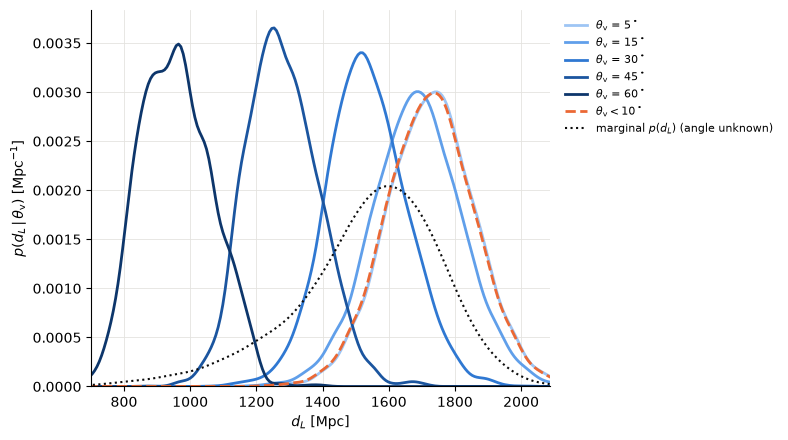

condition                 d_L median [90%] (Mpc)    P(theta_v < theta_0)
theta_v = 5 deg                1729 [1506, 1952]                   0.026
theta_v = 15 deg               1686 [1460, 1916]                   0.219
theta_v = 30 deg               1530 [1339, 1741]                   0.641
theta_v = 45 deg               1273 [1111, 1467]                   0.897
theta_v = 60 deg                 953 [790, 1147]                   0.986
theta_v < 10 deg               1726 [1502, 1950]                        
angle unknown                  1565 [1120, 1858]                        

(an angle far in the tail of p(theta_v), P close to 0 or 1, is conditioned on few samples)


In [11]:
if pe is not None:
    theta_known = (5.0, 15.0, 30.0, 45.0, 60.0)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    rows = []
    for th0, c in zip(theta_known, plotting.blue_steps(len(theta_known))):
        x, p = J.conditional_distance(theta_deg=th0)
        ax.plot(x, p, color=c, lw=2, label=rf"$\theta_{{\rm v}}$ = {th0:.0f}$^\circ$")
        rows.append((rf"theta_v = {th0:.0f} deg", quantiles(x, p), dist_pe.prob_below(th0)))
    x, p = J.conditional_distance(theta_range=(0.0, 10.0))
    ax.plot(x, p, color="#eb6834", lw=2, ls="--", label=r"$\theta_{\rm v} < 10^\circ$")
    rows.append(("theta_v < 10 deg", quantiles(x, p), None))
    x, p = J.marginal_distance()
    ax.plot(x, p, color="#0b0b0b", lw=1.5, ls=":", label=r"marginal $p(d_L)$ (angle unknown)")
    rows.append(("angle unknown", quantiles(x, p), None))
    ax.set_xlim(*np.percentile(d_s, [0.1, 99.9])); ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$d_L$ [Mpc]"); ax.set_ylabel(r"$p(d_L\,|\,\theta_{\rm v})$ [Mpc$^{-1}$]")
    ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    ax.grid(True, color="#e4e3df", lw=0.6); ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(paths.plot_path(source_name, "distance_given_theta_v.png"), dpi=150)
    plt.show()

    print(f"{'condition':<20}{'d_L median [90%] (Mpc)':>28}{'P(theta_v < theta_0)':>24}")
    for lab, q_, pb in rows:
        print(f"{lab:<20}{f'{q_[1]:.0f} [{q_[0]:.0f}, {q_[2]:.0f}]':>28}"
              f"{'' if pb is None else f'{pb:.3f}':>24}")
    print("\n(an angle far in the tail of p(theta_v), P close to 0 or 1, is conditioned on few samples)")

### Check — drawing from it reproduces the posterior

Three ways `sim_3d` could draw, all of which must give back the posterior:

1. **grid joint**: $d$ from $p(d)$, then $\theta$ from the grid's $p(\theta \mid d)$;
2. **grid conditional at the samples' own $d$**: $\theta \mid d_k$ for every PE
   sample $k$ — the path sim_3d takes once its $d_i$ follow the same $p(d)$;
3. **`sample_joint`**: resample PE sample indices and take (RA, Dec, $d$, $\theta$)
   together — the guidelines' "best option", no grid involved.

Compared on the quantiles of both variables and on their correlation.

In [12]:
if pe is not None:
    from scipy.stats import ks_2samp
    n_draw = 200_000
    d_g, t_g = J.sample(n_draw, rng=rng)
    t_c = dist_pe.sample(d_s.size, distance_Mpc=d_s, rng=rng)
    jd = dist_pe.sample_joint(n_draw, rng=rng)
    sets = {"PE samples": (d_s, t_s), "1. grid joint": (d_g, t_g),
            "2. grid theta | d_k": (d_s, t_c), "3. sample_joint": (jd["distance_Mpc"], jd["theta_deg"])}
    print(f"{'':<22}{'theta_v q5/50/95':>22}{'d_L q5/50/95':>22}{'corr(d, cos th)':>17}{'KS(theta) vs PE':>17}")
    for lab, (dd, tt) in sets.items():
        tq, dq = np.percentile(tt, [5, 50, 95]), np.percentile(dd, [5, 50, 95])
        rho = np.corrcoef(dd, np.cos(np.radians(tt)))[0, 1]
        ks = ks_2samp(tt, t_s).statistic
        print(f"{lab:<22}{' / '.join(f'{v:.1f}' for v in tq):>22}{' / '.join(f'{v:.0f}' for v in dq):>22}"
              f"{rho:>17.3f}{ks:>17.4f}")
    print(f"\nsample_joint returns: {sorted(jd)}  (RA/Dec/d/theta of the same PE sample)")

                            theta_v q5/50/95          d_L q5/50/95  corr(d, cos th)  KS(theta) vs PE
PE samples                 6.5 / 24.4 / 51.1    1123 / 1566 / 1849            0.824           0.0000
1. grid joint              7.0 / 24.7 / 51.3    1122 / 1566 / 1857            0.820           0.0122
2. grid theta | d_k        7.1 / 24.6 / 51.0    1123 / 1566 / 1849            0.819           0.0162
3. sample_joint            6.5 / 24.4 / 51.1    1125 / 1565 / 1847            0.823           0.0016

sample_joint returns: ['dec_deg', 'distance_Mpc', 'ra_deg', 'theta_deg']  (RA/Dec/d/theta of the same PE sample)


### Check — the alert skymap's distance vs the PE distance

`sim_3d` draws $d_i$ from the **alert skymap** (Steps 4.1–4.2, per-pixel
`DISTMU/DISTSIGMA/DISTNORM`), then this notebook's $p(\theta \mid d_i)$ from the
**PE** joint. If the two disagree on $p(d)$, the $\theta$ actually drawn is not
the PE $\theta$ marginal: skymap distances in the low-$d$ tail of the PE get the
inclined angles of that tail. Below, the skymap's sky-marginalised $p(d)$ next to
the PE one, and the $\theta_{\rm v}$ distribution each route produces. If the
difference matters, use `sample_joint` (sky position, distance and angle all
from the PE samples) instead of the skymap draw.

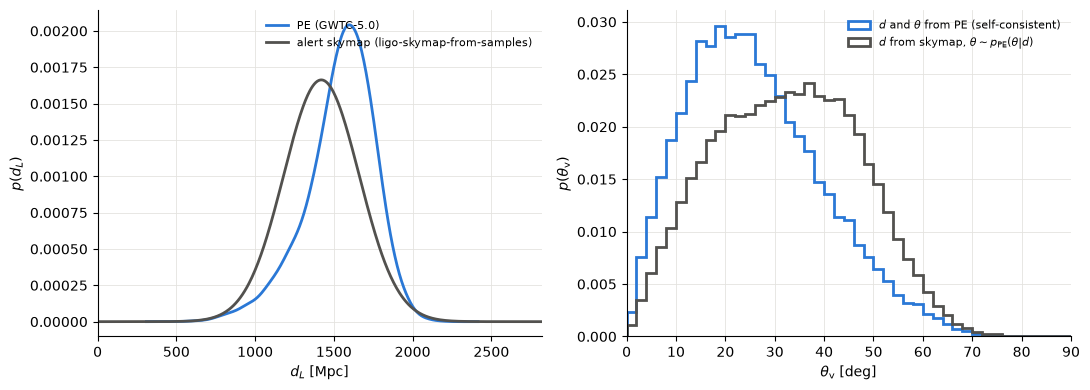

d_L median [90%]:  PE 1566 [1123, 1849]   skymap 1421 [1028, 1815] Mpc
theta_v median:    PE 24.4 deg   skymap-d route 32.6 deg
skymap draws outside the PE distance support: 0.01%
-> drawing d from the skymap shifts the theta_v median by +8.2 deg for this alert: prefer theta_dist.sample_joint(...) (sky, d and theta from the same PE sample).


In [13]:
skymap_file = paths.GW_INPUT_DIR / f"{source_name}.fits"
if pe is not None and skymap_file.exists():
    warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
    from ligo.skymap.io import read_sky_map
    from ligo.skymap.moc import uniq2pixarea
    from ligo.skymap import distance as lsd

    sky = read_sky_map(str(skymap_file), moc=True)   # multi-order: small, never flattened
    mu, sigma, norm = (np.asarray(sky[k], dtype=float) for k in ("DISTMU", "DISTSIGMA", "DISTNORM"))
    prob = np.asarray(sky["PROBDENSITY"] * uniq2pixarea(sky["UNIQ"]), dtype=float)
    prob = np.where(np.isfinite(mu) & (sigma > 0), prob, 0.0); prob /= prob.sum()

    # Steps 4.1-4.2 exactly as sim_3d does them, then theta | d_i from the PE joint
    pix = rng.choice(prob.size, size=100_000, p=prob)
    d_sky = lsd.conditional_ppf(rng.random(pix.size), mu[pix], sigma[pix], norm[pix])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_sky, outside = J.sample_theta_given_distance(d_sky, rng=rng, return_outside=True)

    r = np.linspace(1.0, 1.3 * np.percentile(d_sky, 99.9), 600)
    p_sky = lsd.marginal_pdf(r, prob, mu, sigma, norm)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(*J.marginal_distance(), color=plotting.ANGLE_KIND_COLORS["pe"], lw=2, label=f"PE ({pe.catalog})")
    ax1.plot(r, p_sky, color="#52514e", lw=2, label=f"alert skymap ({sky.meta.get('creator', '')})")
    ax1.set_xlabel(r"$d_L$ [Mpc]"); ax1.set_ylabel(r"$p(d_L)$"); ax1.set_xlim(0, r[-1])
    bins = np.linspace(0, 90, 46)
    ax2.hist(t_s, bins=bins, density=True, histtype="step", lw=2, color=plotting.ANGLE_KIND_COLORS["pe"],
             label=r"$d$ and $\theta$ from PE (self-consistent)")
    ax2.hist(t_sky, bins=bins, density=True, histtype="step", lw=2, color="#52514e",
             label=r"$d$ from skymap, $\theta \sim p_{\rm PE}(\theta|d)$")
    ax2.set_xlabel(r"$\theta_{\rm v}$ [deg]"); ax2.set_ylabel(r"$p(\theta_{\rm v})$"); ax2.set_xlim(0, 90)
    for ax in (ax1, ax2):
        ax.legend(frameon=False, fontsize=8); ax.grid(True, color="#e4e3df", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(paths.plot_path(source_name, "skymap_vs_pe_distance.png"), dpi=150)
    plt.show()

    print(f"d_L median [90%]:  PE {np.median(d_s):.0f} [{np.percentile(d_s, 5):.0f}, {np.percentile(d_s, 95):.0f}]   "
          f"skymap {np.median(d_sky):.0f} [{np.percentile(d_sky, 5):.0f}, {np.percentile(d_sky, 95):.0f}] Mpc")
    print(f"theta_v median:    PE {np.median(t_s):.1f} deg   skymap-d route {np.median(t_sky):.1f} deg")
    print(f"skymap draws outside the PE distance support: {outside.mean():.2%}")
    shift = np.median(t_sky) - np.median(t_s)
    if abs(shift) > 2.0:
        print(f"-> drawing d from the skymap shifts the theta_v median by {shift:+.1f} deg for this alert: "
              "prefer theta_dist.sample_joint(...) (sky, d and theta from the same PE sample).")
else:
    print("no PE or no alert skymap -- check skipped")

### Other alerts with released PE

The same corner for every other alert in the index, for comparison (a nearby,
well-constrained inclination looks very different from a distant, weakly
constrained one).

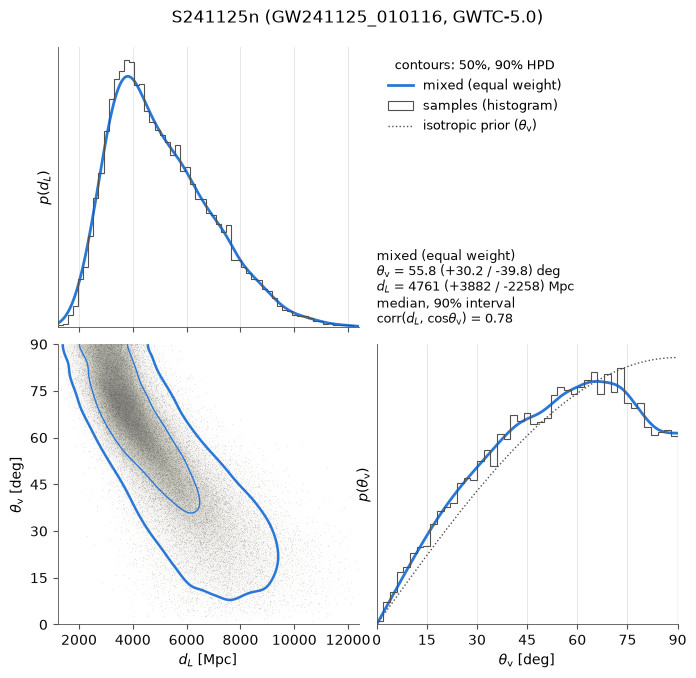

In [14]:
for other in gw_pe.known_alerts():
    if other == source_name:
        continue
    pe_o = gw_pe.load_pe(other)
    J_o = angdist.JointDistanceAngle.from_samples(pe_o.get("distance_Mpc"), pe_o.get("viewing_angle_deg"),
                                                  bw_scale=BW_SCALE)
    plotting.plot_distance_angle_corner(
        {"mixed (equal weight)": J_o}, samples=(pe_o.get("distance_Mpc"), pe_o.get("viewing_angle_deg")),
        title=f"{other} ({pe_o.gw_name}, {pe_o.catalog})",
        save_path=paths.plot_path(other, "theta_v_distance_corner.png"))

## Part 2 — no PE: population and dummy options

For a low-latency alert the public skymap carries no inclination at all. The
options, all normalised per degree so they share one axis (the earlier version
of this plot drew the isotropic curve as a raw $\sin\theta$, unnormalised,
which made it look ~57× larger than the others):

- **Schutz (2011)**: GW detection favours face-on binaries (they are louder), so
  detected sources are *not* isotropic: $p(\theta) \propto \sin\theta\,
  [(1+\cos^2\theta)^2/4 + \cos^2\theta]^{3/2}$. The guidelines' default.
- **selection**: the same effect done explicitly, $p(d, \theta) \propto d^2
  \sin\theta\, P_{\rm det}(d/D_h, \theta)$ with the sky- and
  polarisation-averaged detection probability. Its $d$-marginal is (almost)
  Schutz; its conditional $p(\theta \mid d)$ tilts face-on as $d \to D_h$. It needs
  a horizon $D_h$ for the source type and network, which the alert does not
  give — `HORIZON_MPC` is illustrative here.
- **isotropic**: $\sin\theta$, no selection — the most pessimistic for an
  on-axis counterpart.
- **fixed** / **two_bin**: placeholders with no claimed shape.

The PE marginal is overlaid (if available) to show how much an event-specific
posterior can differ from any population prior. The grey bands mark the angles
of the model files (`data/models/grb_afterglow_inaf/raw`).

model file angles [deg]: [9.07, 13.17, 22.63, 28.55, 77.84]


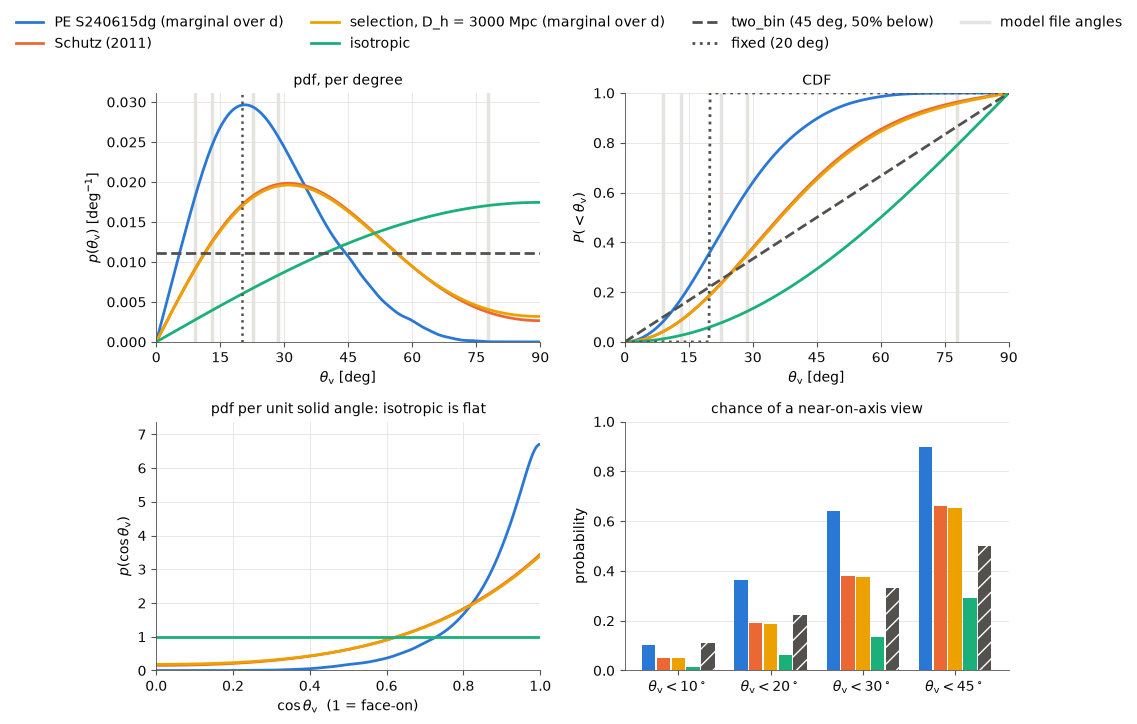

option                                            median    mean   P(<10)   P(<20)   P(<30)
PE S240615dg (marginal over d)                      24.7    26.4    0.101    0.362    0.641
Schutz (2011)                                       36.2    38.2    0.051    0.190    0.378
selection, D_h = 3000 Mpc (marginal over d)         36.5    38.7    0.051    0.188    0.374
isotropic                                           60.0    57.3    0.015    0.060    0.134
two_bin (45 deg, 50% below)                         45.0    45.0    0.111    0.222    0.333
fixed (20 deg)                                      20.0    20.0    0.000    0.000    1.000


In [15]:
from astropy.io import fits
model_angles = sorted(float(fits.getheader(f)["ANGLE"]) for f in sorted(paths.GRB_MODEL_RAW_DIR.glob("*.fits")))
print("model file angles [deg]:", [round(a, 2) for a in model_angles])

dist_schutz    = angdist.make_theta_distribution("schutz")
dist_selection = angdist.make_theta_distribution("selection", horizon_Mpc=HORIZON_MPC)
dist_isotropic = angdist.make_theta_distribution("isotropic")
dist_two_bin   = angdist.make_theta_distribution("two_bin", **TWO_BIN)
dist_fixed     = angdist.make_theta_distribution("fixed", theta_deg=FIXED_THETA_DEG)

options = {}
if dist_pe is not None:
    options[f"PE {source_name} (marginal over d)"] = dist_pe
options.update({
    "Schutz (2011)": dist_schutz,
    f"selection, D_h = {HORIZON_MPC:.0f} Mpc (marginal over d)": dist_selection,
    "isotropic": dist_isotropic,
    f"two_bin ({TWO_BIN['threshold_deg']:.0f} deg, {100 * TWO_BIN['p_below']:.0f}% below)": dist_two_bin,
    f"fixed ({FIXED_THETA_DEG:.0f} deg)": dist_fixed,
})
plotting.plot_theta_distribution_comparison(
    options, model_angles=model_angles,
    save_path=paths.plot_path(source_name, "theta_v_options_comparison.png"))

print(f"{'option':<48}{'median':>8}{'mean':>8}{'P(<10)':>9}{'P(<20)':>9}{'P(<30)':>9}")
for lab, D in options.items():
    g, cdf = D.cdf_grid(theta_grid_deg=np.linspace(0, 90, 9001))
    med = np.interp(0.5, cdf, g) if D.kind != "fixed" else D.theta_fixed_deg
    mean = np.trapezoid(1.0 - cdf, g)
    print(f"{lab:<48}{med:>8.1f}{mean:>8.1f}" + "".join(f"{D.prob_below(t):>9.3f}" for t in (10, 20, 30)))

### Check — each sampler draws what its pdf says

200k draws per option against its own tabulated pdf; the KS distance (largest
CDF difference) should be at the $1/\sqrt{n}$ noise level. Distance-dependent
options are drawn at one reference distance here (the PE median, or $D_h/2$).

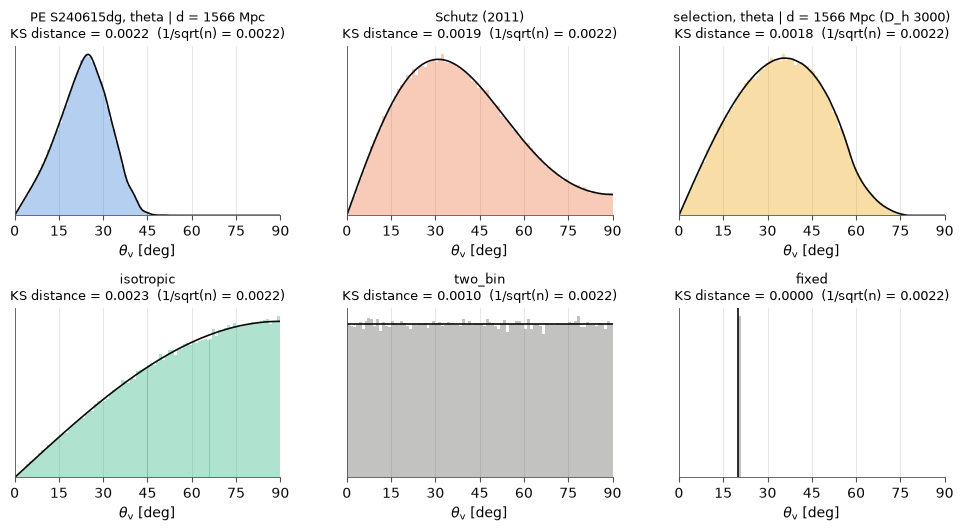

In [16]:
d_ref = float(np.median(d_s)) if dist_pe is not None else 0.5 * HORIZON_MPC
check = {}
if dist_pe is not None:
    check[f"PE {source_name}, theta | d = {d_ref:.0f} Mpc"] = dist_pe
check.update({"Schutz (2011)": dist_schutz,
              f"selection, theta | d = {d_ref:.0f} Mpc (D_h {HORIZON_MPC:.0f})": dist_selection,
              "isotropic": dist_isotropic, "two_bin": dist_two_bin, "fixed": dist_fixed})
plotting.plot_theta_sampler_check(check, distance_Mpc=d_ref,
                                  save_path=paths.plot_path(source_name, "theta_v_sampler_check.png"))

### Check — where does Schutz come from? (the "selection" model)

For sources uniform in volume and isotropic in orientation, a single detector
sees a source at $(d, \theta)$ if its orientation factor $\Theta/4 > d/D_h$
(Finn & Chernoff 1993). Averaged over sky position and polarisation, the
$d$-marginal of the detected population is $\sin\theta\,\langle(\Theta/4)^3\rangle$;
Schutz's closed form replaces $\langle\Theta^3\rangle$ by $\langle\Theta^2\rangle^{3/2}$.
Left: how close that approximation is. Right: the part Schutz throws away —
$p(\theta \mid d)$ at fixed $d/D_h$: nearby sources can be at any angle, sources
close to the horizon are only detected face-on. This is the same degeneracy the
PE ridge shows for one event, here at the population level.

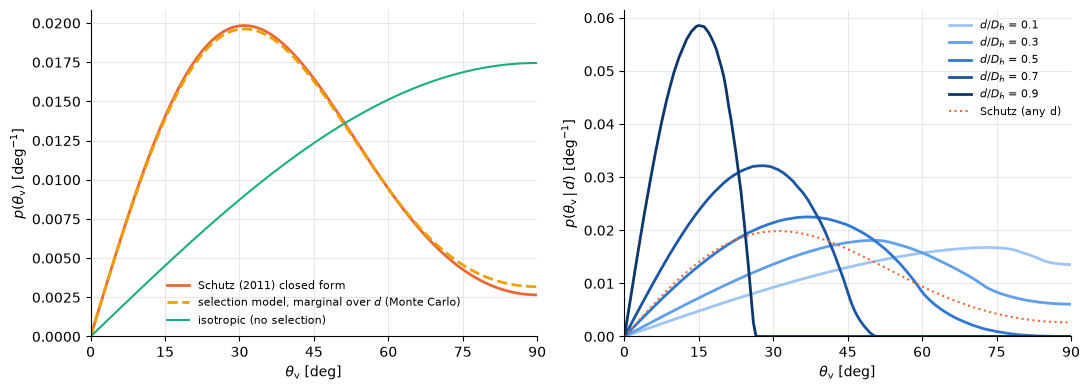

median: Schutz 36.2 deg, selection 36.5 deg; peak: 31.0 vs 31.0 deg; max |CDF difference| = 0.009
  d/D_h = 0.1: median theta_v =  58.2 deg, P(theta_v < 20) = 0.064
  d/D_h = 0.3: median theta_v =  47.7 deg, P(theta_v < 20) = 0.097
  d/D_h = 0.5: median theta_v =  35.8 deg, P(theta_v < 20) = 0.179
  d/D_h = 0.7: median theta_v =  25.8 deg, P(theta_v < 20) = 0.321
  d/D_h = 0.9: median theta_v =  14.2 deg, P(theta_v < 20) = 0.825


In [17]:
g = np.linspace(0, 90, 361)
_, p_sel = dist_selection.pdf_grid(theta_grid_deg=g)
p_sch, p_iso = angdist.schutz_pdf(g), angdist.isotropic_pdf(g)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(g, p_sch, color=plotting.ANGLE_KIND_COLORS["schutz"], lw=2, label="Schutz (2011) closed form")
ax1.plot(g, p_sel, color=plotting.ANGLE_KIND_COLORS["selection"], lw=2, ls="--",
         label=r"selection model, marginal over $d$ (Monte Carlo)")
ax1.plot(g, p_iso, color=plotting.ANGLE_KIND_COLORS["isotropic"], lw=1.5, label="isotropic (no selection)")
ax1.set_ylabel(r"$p(\theta_{\rm v})$ [deg$^{-1}$]")
fracs = (0.1, 0.3, 0.5, 0.7, 0.9)
for x, c in zip(fracs, plotting.blue_steps(len(fracs))):
    _, p = dist_selection.pdf_grid(distance_Mpc=x * HORIZON_MPC, theta_grid_deg=g)
    ax2.plot(g, p, color=c, lw=2, label=rf"$d/D_h$ = {x}")
ax2.plot(g, p_sch, color=plotting.ANGLE_KIND_COLORS["schutz"], lw=1.5, ls=":", label="Schutz (any d)")
ax2.set_ylabel(r"$p(\theta_{\rm v}\,|\,d)$ [deg$^{-1}$]")
for ax in (ax1, ax2):
    ax.set_xlim(0, 90); ax.set_xticks(np.arange(0, 91, 15)); ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$\theta_{\rm v}$ [deg]"); ax.legend(frameon=False, fontsize=8)
    ax.grid(True, color="#e4e3df", lw=0.6); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(paths.plot_path(source_name, "selection_vs_schutz.png"), dpi=150)
plt.show()

cdf = lambda p: np.concatenate([[0], np.cumsum(0.5 * (p[1:] + p[:-1]) * np.diff(g))])
print(f"median: Schutz {quantiles(g, p_sch, (0.5,))[0]:.1f} deg, selection {quantiles(g, p_sel, (0.5,))[0]:.1f} deg; "
      f"peak: {g[np.argmax(p_sch)]:.1f} vs {g[np.argmax(p_sel)]:.1f} deg; "
      f"max |CDF difference| = {np.max(np.abs(cdf(p_sch) - cdf(p_sel))):.3f}")
for x in fracs:
    _, p = dist_selection.pdf_grid(distance_Mpc=x * HORIZON_MPC, theta_grid_deg=g)
    print(f"  d/D_h = {x}: median theta_v = {quantiles(g, p, (0.5,))[0]:5.1f} deg, "
          f"P(theta_v < 20) = {dist_selection.prob_below(20, distance_Mpc=x * HORIZON_MPC):.3f}")

### Where the choice reaches the upper limit: which model file gets used

`sim_3d` only has model files at a few angles; each drawn $\theta_i$ is mapped
to one of them (`GRBModelSet.get_model`, Step 5). The fraction of iterations
that end up on each file is what actually differs between the options — for
example, how much weight goes to the far off-axis file, where the afterglow is
much fainter and later. Nearest-angle (Option A) below; the stochastic split
(Option B) is in the table.

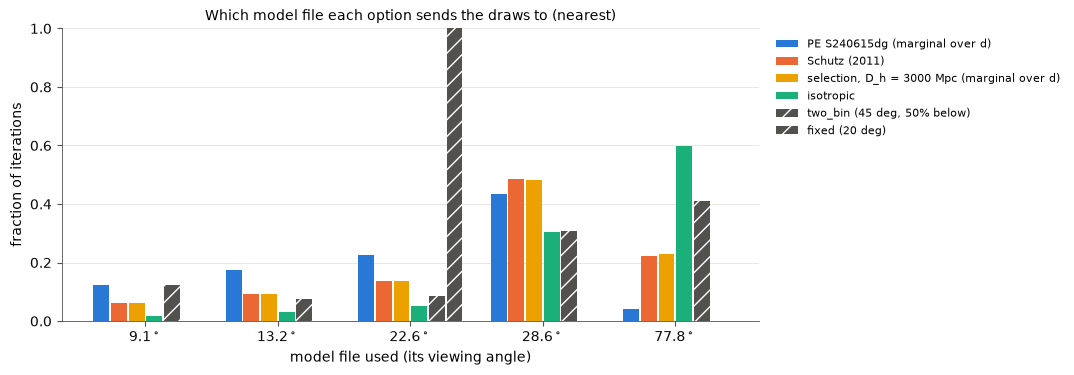


nearest: fraction of iterations per model file
option                                                9.1     13.2     22.6     28.6     77.8
PE S240615dg (marginal over d)                      0.124    0.176    0.225    0.435    0.040
Schutz (2011)                                       0.063    0.092    0.137    0.487    0.221
selection, D_h = 3000 Mpc (marginal over d)         0.062    0.091    0.135    0.482    0.230
isotropic                                           0.019    0.030    0.050    0.303    0.599
two_bin (45 deg, 50% below)                         0.124    0.075    0.086    0.307    0.409
fixed (20 deg)                                      0.000    0.000    1.000    0.000    0.000

stochastic: fraction of iterations per model file
option                                                9.1     13.2     22.6     28.6     77.8
PE S240615dg (marginal over d)                      0.125    0.177    0.222    0.384    0.092
Schutz (2011)                                       0.0

In [18]:
plotting.plot_model_angle_assignment(options, model_angles, method="nearest",
                                     save_path=paths.plot_path(source_name, "theta_v_model_file_weights.png"))

for method in ("nearest", "stochastic"):
    print(f"\n{method}: fraction of iterations per model file")
    print(f"{'option':<48}" + "".join(f"{a:>9.1f}" for a in model_angles))
    for lab, D in options.items():
        w = plotting.model_angle_weights(D, model_angles, method=method)
        print(f"{lab:<48}" + "".join(f"{v:>9.3f}" for v in w))

## Choose the distribution to use for this alert

Assign the one that applies to `theta_distribution` — it is the one object that
gets saved and that `sim_3d` loads back. Default: the PE joint when the alert has
released PE, else Schutz.

In [19]:
# Edit this line to select whichever case applies to this alert:
theta_distribution = dist_pe if dist_pe is not None else dist_schutz

print(f"Using kind={theta_distribution.kind!r} for {source_name}"
      + (" -- theta depends on d: sim_3d must pass each iteration's distance"
         if theta_distribution.depends_on_distance else ""))

Using kind='pe' for S240615dg -- theta depends on d: sim_3d must pass each iteration's distance


## Save the standardized cache

In [20]:
out_path = paths.theta_distribution_path(source_name)
angdist.save_theta_distribution(theta_distribution, out_path)
print(f"Wrote {out_path.relative_to(paths.REPO_ROOT)} ({out_path.stat().st_size / 1e6:.2f} MB)")

# Round trip: the reloaded object must draw exactly what the saved one does.
reloaded = angdist.load_theta_distribution(out_path)
assert reloaded.kind == theta_distribution.kind
d_test = np.linspace(*np.percentile(d_s, [10, 90]), 5) if theta_distribution.depends_on_distance else None
a_ = theta_distribution.sample(5, distance_Mpc=d_test, rng=np.random.default_rng(1))
b_ = reloaded.sample(5, distance_Mpc=d_test, rng=np.random.default_rng(1))
assert np.allclose(a_, b_), (a_, b_)
print(f"reloaded kind={reloaded.kind!r}; identical draws: {np.round(b_, 2)}"
      + (f" at d = {np.round(d_test)} Mpc" if d_test is not None else ""))

Wrote data/gw_input/S240615dg_theta_distribution.npz (0.86 MB)
reloaded kind='pe'; identical draws: [43.51 46.41 16.34 32.77 11.39] at d = [1240. 1377. 1515. 1652. 1789.] Mpc


## How `sim_3d` consumes this

```python
from gwuls import angle_distribution as angdist, paths

theta_dist = angdist.load_theta_distribution(paths.theta_distribution_path(source_name))

# Steps 4.1-4.2 draw d_i from the alert skymap (all N iterations at once is fine):
theta_i = theta_dist.sample(N, distance_Mpc=d_draws, rng=rng)   # p(theta | d_i), one per d_i
# distance_Mpc is required for kind "pe"/"selection" and ignored otherwise.

# With PE ("pe" kind), the guidelines' best option replaces Steps 4.1-4.3 altogether:
draw = theta_dist.sample_joint(N, rng=rng)   # ra_deg, dec_deg, distance_Mpc, theta_deg of the same PE sample

# "The angle is known": the distance distribution for it, from the same joint
d, p_d = theta_dist.joint.conditional_distance(theta_deg=20.0)          # or theta_range=(0, 10)
```

Distances outside the PE support are clipped to its edge (with a warning that
counts them); see the skymap-vs-PE check above for how often that happens.